## Delta hedging of a sold European call


Business context: 
- We sold 1 x ATM European Call option to a client.
- We hedge the underlying via delta.


**Goal:** Can a *discrete* delta hedge replicate a European call under Black–Scholes?

We study how hedging error depends on:
- **Rebalancing frequency:** daily vs. weekly  
- **Volatility mis-specification:** using a hedge volatility $\sigma_{\text{hedge}}$ different from the true volatility $\sigma_{\text{true}}$

**Setup**
- The underlying follows a **Geometric Brownian Motion (GBM)** with constant volatility $\sigma_{\text{true}}$ under risk-neutral drift $\mu = r - q$.
- We short $1\times$ European **call** at $t=0$ and hedge with the **stock**.
- At each rebalance time we set the hedge to the **Black–Scholes delta** computed with model volatility $\sigma_{\text{hedge}}$.
- Cash accrues at the continuous rate $r$.

**Portfolio and hedging error**

Let $V_t$ be the option value, $\Delta_t$ the hedge ratio, $S_t$ the stock price, and $B_t$ the cash account.

We track the self-financing portfolio value
$$
H_t = -V_t + \Delta_t S_t + B_t 
$$

**Initial financing intuition**

Selling the option generates premium $V_0$, which is used to fund the initial delta hedge. Therefore,
$$
B_0 = V_0 - \Delta_0 S_0 
$$

Between rebalancing times, the cash account accrues interest:
$$
B_{t+\Delta t} = B_t \, e^{r \Delta t}
$$

When rebalancing, changes in the stock position are financed from the cash account (self-financing).

The **terminal hedging error** is
$$
H_T = -\text{payoff}(S_T) + \Delta_T S_T + B_T 
$$

With continuous rebalancing and correct volatility, $H_T = 0$. In practice, discretization and volatility mis-specification imply $H_T \neq 0$





In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from qp import bs_price, bs_greeks, accrue_cash, rebalance_delta_hedge, hedge_portfolio_value
from qp import var_historical, es_historical 

#---- Parameters ----
# Underlying and Option
S0 = 100.0              # initial spot 
K = 100.0               # strike    
r = 0.02                # risk-free
q = 0.00              # dividend yield 
T = 1.0                 # time to maturity in years
option_type = "call"    

sigma_true = 0.20       # "realized" vol used in GBM 
sigma_hedge = 0.20      # model vol 

days_per_year = 252 
dt = 1.0 / days_per_year
n_steps = int(T * days_per_year)

rng = np.random.default_rng(7)

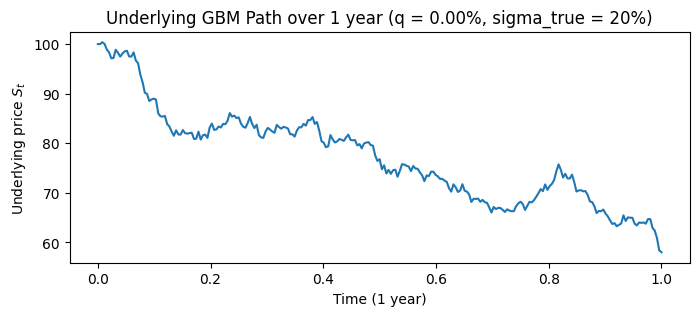

In [2]:
# GBM simulation under risk-neutral drift mu = r - q
def simulate_gbm(
        S0: float, 
        mu: float, 
        sigma: float, 
        dt: float, 
        n_steps: int, 
        rng
) -> np.ndarray:
    """
    One GBM path: dS = mu * S * dt + sigma * S * dW.
    We discretize: log-returns per step are Normal with mean (mu - 0.5*sigma^2)*dt
    and std sigma*sqrt(dt).
    """
    Z = rng.standard_normal(n_steps)
    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    S = np.empty(n_steps + 1)
    S[0] = S0
    S[1:] = S0 * np.exp(np.cumsum(increments))
    return S

# simulate ONE path
S_path = simulate_gbm(S0, r - q, sigma_true, dt, n_steps, rng)


tgrid = np.arange(n_steps + 1) * dt
plt.figure(figsize=(8,3))
plt.plot(tgrid, S_path)
plt.title(f"Underlying GBM Path over 1 year (q = {q:.2%}, sigma_true = {sigma_true:.0%})")
plt.xlabel("Time (1 year)")
plt.ylabel("Underlying price $S_t$")
plt.show()

,S,Option,Portfolio,Delta,Cash
0,100.000000,8.916037,0.000000,0.579260,-49.009934
1,100.001550,8.916037,-0.003890,0.579260,-49.013823
2,100.378649,8.897511,0.011644,0.579135,-49.005216
3,100.032558,9.097780,0.025877,0.586354,-49.733801
4,98.916426,8.876524,0.040254,0.579433,-49.045395


,S,Option,Portfolio,Delta,Cash
248,62.940713,0.0,0.284931,0.0,0.284931
249,62.394300,0.0,0.284954,0.0,0.284954
250,60.865677,0.0,0.284977,0.0,0.284977
251,58.422737,0.0,0.284999,0.0,0.284999
252,58.033842,0.0,0.285022,0.0,0.285022


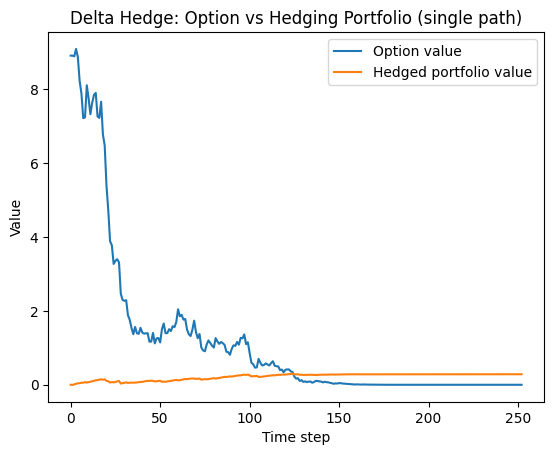

Terminal Hedge Error = 0.28502193424003475


In [3]:
def delta_hedge_one_path(
    S_path: np.ndarray,
    S0: float, K: float, r: float, q: float,
    sigma_hedge: float, T: float, option_type: str,
    dt: float, rebalance_steps: int = 1,
    option_qty: float = -1.0,
    tc_per_dollar: float = 0.0,
):
    """
    Discrete, self-financing delta hedge on a single path.

    - option_qty = -1.0 -> short 1 option (sold to client)
    - tc_per_dollar models linear transaction costs on traded notional:
        cost = tc_per_dollar * |Δdelta| * S

    Tracks: option value V_t, stock hedge delta_t, cash B_t and total portfolio value:
        H_t = option_qty * V_t + delta_t * S_t + B_t
    Terminal hedging error uses option payoff at maturity as V_T.
    """
    n_steps = len(S_path) - 1

    # t=0: option price & delta (model sigma_hedge)
    V0 = bs_price(S0, K, r, q, sigma_hedge, T, option_type)
    delta = bs_greeks(S0, K, r, q, sigma_hedge, T, option_type)["delta"]

    # Self-financing initialization: sell/buy option (option_qty) and buy delta shares
    B = -option_qty * V0 - delta * S0

    # storage
    deltas = np.zeros(n_steps + 1); deltas[0] = delta
    cash   = np.zeros(n_steps + 1); cash[0]   = B
    optval = np.zeros(n_steps + 1); optval[0] = V0
    H      = np.zeros(n_steps + 1); H[0]      = hedge_portfolio_value(V0, option_qty, delta, S0, B)

    costs_paid = np.zeros(n_steps + 1)
    turnover   = np.zeros(n_steps + 1)

    for t in range(n_steps):
        # accrue cash
        B = accrue_cash(B, r, dt)

        S_t = float(S_path[t])
        tau = max(T - t * dt, 0.0)

        # rebalance at chosen frequency (and at last step)
        if (t % rebalance_steps == 0) or (t == n_steps - 1):
            delta_new = bs_greeks(S_t, K, r, q, sigma_hedge, tau, option_type)["delta"]
            B, cost, traded_notional = rebalance_delta_hedge(
                B, delta_old=delta, delta_new=delta_new, S=S_t, tc_per_dollar=tc_per_dollar
            )
            costs_paid[t+1] = cost
            turnover[t+1]   = traded_notional
            delta = delta_new

        # mark-to-market
        V_t = bs_price(S_t, K, r, q, sigma_hedge, tau, option_type)
        H_t = hedge_portfolio_value(V_t, option_qty, delta, S_t, B)

        deltas[t+1] = delta
        cash[t+1]   = B
        optval[t+1] = V_t
        H[t+1]      = H_t

    ST = float(S_path[-1])
    payoff = max(ST - K, 0.0) if option_type == "call" else max(K - ST, 0.0)
    H_T = hedge_portfolio_value(payoff, option_qty, delta, ST, B)

    return {
        "deltas": deltas,
        "cash": cash,
        "option": optval,
        "portfolio": H,
        "hedge_error_T": float(H_T),
        "costs_paid": costs_paid,
        "turnover": turnover,
        "total_cost": float(np.sum(costs_paid)),
        "total_turnover": float(np.sum(turnover)),
    }


# --- run on a single path (no transaction costs) ---
res = delta_hedge_one_path(
    S_path, S0, K, r, q, sigma_hedge, T, option_type,
    dt=dt, rebalance_steps=1,
    option_qty=-1.0,
    tc_per_dollar=0.0
)

df = pd.DataFrame({
    "S": S_path,
    "Option": res["option"],
    "Portfolio": res["portfolio"],
    "Delta": res["deltas"],
    "Cash": res["cash"],
})

display(df.head())
display(df.tail())

plt.figure()
plt.plot(df["Option"], label="Option value")
plt.plot(df["Portfolio"], label="Hedged portfolio value")
plt.title("Delta Hedge: Option vs Hedging Portfolio (single path)")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.show()

print("Terminal Hedge Error =", res["hedge_error_T"])


## Monte Carlo Simulation for mean, std and MSHE

In [4]:
def mc_hedge_errors(
    N: int,
    rebalance_steps: int,
    sigma_hedge: float,
    tc_bps: float = 0.0,
    *,
    S0=S0, K=K, r=r, q=q, T=T, option_type=option_type,
    dt=dt, n_steps=n_steps,
    option_qty: float = -1.0,
):
    """Simulate N paths, return terminal hedging errors + MSHE (+ turnover/costs)."""
    rng_local = np.random.default_rng(123)
    errors = np.empty(N, dtype=float)
    turns  = np.empty(N, dtype=float)
    costs  = np.empty(N, dtype=float)

    tc_per_dollar = tc_bps / 1e4

    for i in range(N):
        Z = rng_local.standard_normal(n_steps)
        increments = (r - q - 0.5 * sigma_true**2) * dt + sigma_true * np.sqrt(dt) * Z

        S = np.empty(n_steps + 1)
        S[0] = S0
        S[1:] = S0 * np.exp(np.cumsum(increments))

        out = delta_hedge_one_path(
            S, S0, K, r, q, sigma_hedge, T, option_type,
            dt=dt, rebalance_steps=rebalance_steps,
            option_qty=option_qty,
            tc_per_dollar=tc_per_dollar
        )

        errors[i] = out["hedge_error_T"]
        turns[i]  = out["total_turnover"]
        costs[i]  = out["total_cost"]

    mshe = float(np.mean(errors**2))
    return errors, mshe, turns, costs


# --- Compare hedging error across scenarios (no transaction costs) ---
scenarios = [
    ("daily, correct vol",  1,  sigma_true),
    ("weekly, correct vol", 5,  sigma_true),
    ("daily, low vol",      1,  0.8 * sigma_true),
    ("weekly, low vol",     5,  0.8 * sigma_true),
    ("daily, high vol",     1,  1.2 * sigma_true),
    ("weekly, high vol",    5,  1.2 * sigma_true),
]

all_errors = {}
records = []

for name, step, sig_h in scenarios:
    errs, mshe, turns, costs = mc_hedge_errors(N=500, rebalance_steps=step, sigma_hedge=sig_h, tc_bps=0.0)
    all_errors[name] = errs
    records.append({
        "scenario": name,
        "rebalance_steps": step,
        "sigma_hedge": sig_h,
        "mean_H_T": float(np.mean(errs)),
        "std_H_T": float(np.std(errs, ddof=1)),
        "MSHE": mshe
    })

df_results = pd.DataFrame(records).sort_values("scenario").reset_index(drop=True)
df_results


,scenario,rebalance_steps,sigma_hedge,mean_H_T,std_H_T,MSHE
0,"daily, correct vol",1,0.20,0.029303,0.453777,0.206361
1,"daily, high vol",1,0.24,1.635646,0.742894,3.226124
2,"daily, low vol",1,0.16,-1.580067,0.789769,3.119100
3,"weekly, correct vol",5,0.20,0.044433,0.959640,0.921042
4,"weekly, high vol",5,0.24,1.641638,1.119716,3.946232
5,"weekly, low vol",5,0.16,-1.550195,1.162897,3.752727


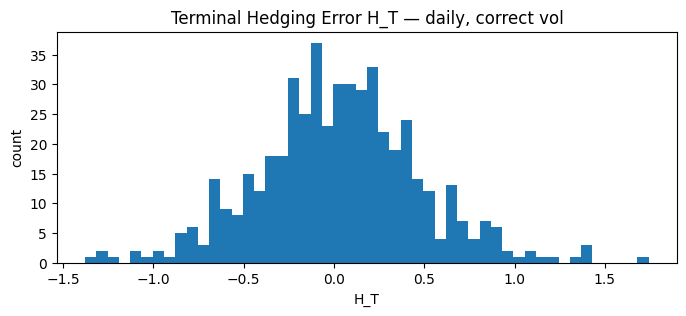

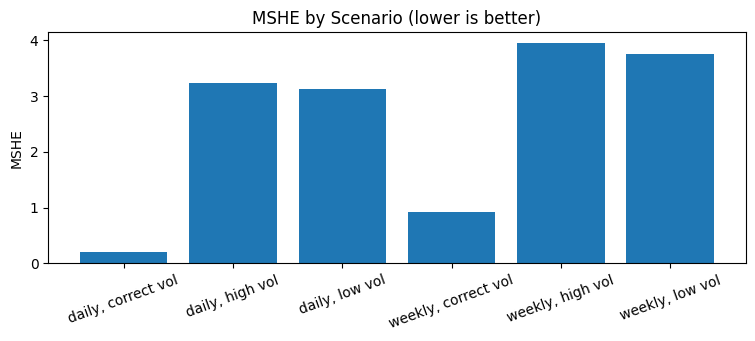

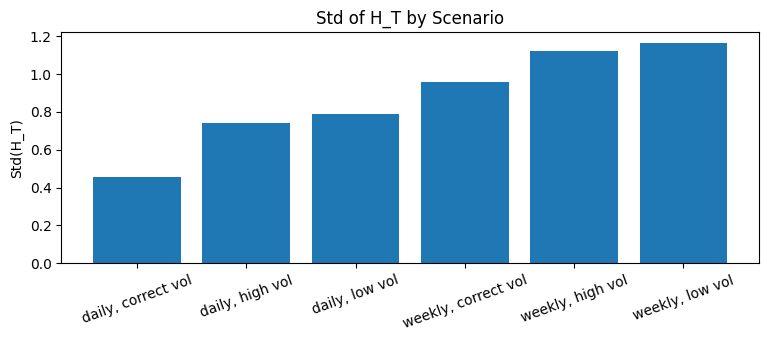

In [5]:
errs_example = all_errors["daily, correct vol"]
plt.figure(figsize=(8,3))
plt.hist(errs_example, bins=50)
plt.title("Terminal Hedging Error H_T — daily, correct vol")
plt.xlabel("H_T"); plt.ylabel("count")
plt.show()

plt.figure(figsize=(9,3))
plt.bar(df_results["scenario"], df_results["MSHE"])
plt.title("MSHE by Scenario (lower is better)")
plt.xticks(rotation=20)
plt.ylabel("MSHE")
plt.show()

plt.figure(figsize=(9,3))
plt.bar(df_results["scenario"], df_results["std_H_T"])
plt.title("Std of H_T by Scenario")
plt.xticks(rotation=20)
plt.ylabel("Std(H_T)")
plt.show()

The results confirm that discrete hedging produces residual error even with the correct model, and that hedging less frequently (weekly) significantly increases risk. More importantly, using a mis-specified volatility leads to systematic P&L bias – highlighting the importance of model risk for option desks

## Implementing Transaction Costs, VaR, CVaR and Moneyness sweep 

In [6]:
# Transaction costs are handled via `tc_per_dollar` inside `delta_hedge_one_path`.
# Example: run the same single path hedge with 1bp transaction costs per $ traded.

tc_bps = 1.0
res_tc = delta_hedge_one_path(
    S_path, S0, K, r, q, sigma_hedge, T, option_type,
    dt=dt, rebalance_steps=1,
    option_qty=-1.0,
    tc_per_dollar=tc_bps/1e4
)

print("Total turnover =", res_tc["total_turnover"])
print("Total transaction cost =", res_tc["total_cost"])
print("Terminal Hedge Error (with costs) =", res_tc["hedge_error_T"])


Total turnover = 152.7459748347722
Total transaction cost = 0.01527459748347722
Terminal Hedge Error (with costs) = 0.2695136636042796


(Monte Carlo helper function `mc_hedge_errors` is defined above and supports transaction costs via `tc_bps`.)


In [7]:

scenarios = [
    ("daily, correct vol, 0bps",   1, sigma_true, 0.0),
    ("daily, correct vol, 10bps",  1, sigma_true, 10.0),
    ("weekly, correct vol, 0bps",  5, sigma_true, 0.0),
    ("weekly, correct vol, 10bps", 5, sigma_true, 10.0),
]

recs = []; errs_map = {}
for name, step, sig_h, tc in scenarios:
    errs, mshe, turns, costs = mc_hedge_errors(400, step, sig_h, tc_bps=tc)
    recs.append({
        "scenario": name,
        "rebalance_steps": step,
        "tc_bps": tc,
        "MSHE": mshe,
        "mean_H_T": float(np.mean(errs)),
        "std_H_T": float(np.std(errs, ddof=1)),
        "mean_turnover": float(np.mean(turns)),
        "mean_cost": float(np.mean(costs)),
    })
    errs_map[name] = errs

df_cost = pd.DataFrame(recs)
df_cost

,scenario,rebalance_steps,tc_bps,MSHE,mean_H_T,std_H_T,mean_turnover,mean_cost
0,"daily, correct vol, 0bps",1,0.0,0.192443,0.019160,0.438813,502.061568,0.000000
1,"daily, correct vol, 10bps",1,10.0,0.463778,-0.487863,0.475745,502.061568,0.502062
2,"weekly, correct vol, 0bps",5,0.0,0.916125,0.010107,0.958289,228.875349,0.000000
3,"weekly, correct vol, 10bps",5,10.0,0.990334,-0.220958,0.971530,228.875349,0.228875


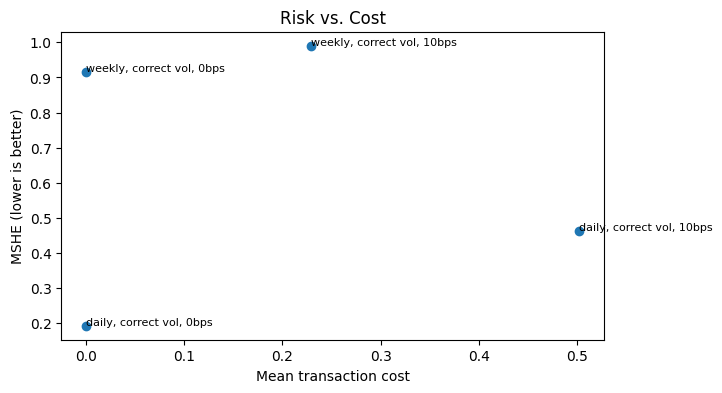

In [8]:
plt.figure(figsize=(7,4))
plt.scatter(df_cost["mean_cost"], df_cost["MSHE"])
for i, row in df_cost.iterrows():
    plt.annotate(row["scenario"], (row["mean_cost"], row["MSHE"]), fontsize=8)
plt.xlabel("Mean transaction cost"); plt.ylabel("MSHE (lower is better)")
plt.title("Risk vs. Cost")
plt.show()

In [9]:
def risk_metrics(errors: np.ndarray, level=0.99):
    # errors = terminal hedging errors H_T
    vaR = var_historical(errors, level=level, input_is_loss=False)
    es  = es_historical(errors, level=level, input_is_loss=False)
    return float(vaR), float(es)

rows = []
for name, arr in errs_map.items():
    vaR99, es99 = risk_metrics(arr, level=0.99)
    rows.append({"scenario": name, "VaR(99%)": vaR99, "ES(99%)": es99})
pd.DataFrame(rows).sort_values("scenario")

,scenario,VaR(99%),ES(99%)
0,"daily, correct vol, 0bps",0.977428,1.104173
1,"daily, correct vol, 10bps",1.678224,1.796033
2,"weekly, correct vol, 0bps",2.501929,2.765224
3,"weekly, correct vol, 10bps",2.811938,3.121370


In [10]:
def study_moneyness(moneyness_list=(0.9, 1.0, 1.1), rebalance_steps=1, tc_bps=0.0):
    recs = []
    for m in moneyness_list:
        K_local = S0 * m
        errs, mshe, turns, costs = mc_hedge_errors(400, rebalance_steps, sigma_true, tc_bps=tc_bps,
                                                   S0=S0, K=K_local, r=r, q=q, T=T,
                                                   option_type=option_type, dt=dt, n_steps=n_steps)
        recs.append({"moneyness K/S0": m, "MSHE": mshe,
                     "std_H_T": float(np.std(errs, ddof=1)),
                     "mean_cost": float(np.mean(costs))})
    return pd.DataFrame(recs).sort_values("moneyness K/S0")

df_mny = study_moneyness(moneyness_list=(0.9, 1.0, 1.1), rebalance_steps=1, tc_bps=0.0)
df_mny

,moneyness K/S0,MSHE,std_H_T,mean_cost
0,0.9,0.121577,0.348841,0.0
1,1.0,0.192443,0.438813,0.0
2,1.1,0.219715,0.469270,0.0


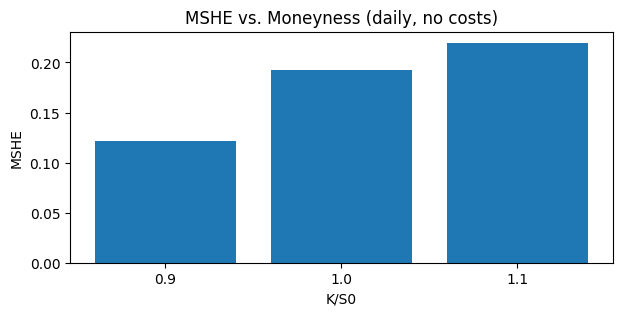

In [11]:
plt.figure(figsize=(7,3))
plt.bar(df_mny["moneyness K/S0"].astype(str), df_mny["MSHE"])
plt.title("MSHE vs. Moneyness (daily, no costs)"); plt.xlabel("K/S0"); plt.ylabel("MSHE")
plt.show()